In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r'D:\Triage Acuity Project\triagegeist\train.csv')
df.head()

,patient_id,site_id,triage_nurse_id,arrival_mode,arrival_hour,arrival_day,arrival_month,arrival_season,shift,age,...,gcs_total,pain_score,weight_kg,height_cm,bmi,shock_index,news2_score,disposition,ed_los_hours,triage_acuity
0,TG-UXRGA9UCO,SITE-TMP-01,NURSE-0033,walk-in,6,Monday,5,spring,morning,43,...,14,7,52.3,165.4,19.1,0.725,8,discharged,7.35,2
1,TG-B19DBBS2G,SITE-HEL-01,NURSE-0001,walk-in,6,Thursday,4,spring,morning,72,...,15,-1,73.3,164.4,27.1,0.739,1,discharged,0.70,5
2,TG-GZ97W7M6V,SITE-HEL-02,NURSE-0005,walk-in,8,Saturday,4,spring,morning,82,...,15,3,77.1,183.7,22.8,0.798,2,discharged,0.63,5
3,TG-THIB2TN9Q,SITE-HEL-02,NURSE-0026,police,7,Sunday,3,spring,morning,50,...,15,7,49.6,172.6,16.6,0.812,2,discharged,1.99,3
4,TG-J3U3LQ2QY,SITE-HEL-02,NURSE-0044,walk-in,5,Tuesday,5,spring,night,62,...,15,4,71.9,173.4,23.9,0.812,2,transferred,3.58,3


In [ ]:
df.columns

Index(['patient_id', 'site_id', 'triage_nurse_id', 'arrival_mode',
       'arrival_hour', 'arrival_day', 'arrival_month', 'arrival_season',
       'shift', 'age', 'age_group', 'sex', 'language', 'insurance_type',
       'transport_origin', 'pain_location', 'mental_status_triage',
       'chief_complaint_system', 'num_prior_ed_visits_12m',
       'num_prior_admissions_12m', 'num_active_medications',
       'num_comorbidities', 'systolic_bp', 'diastolic_bp',
       'mean_arterial_pressure', 'pulse_pressure', 'heart_rate',
       'respiratory_rate', 'temperature_c', 'spo2', 'gcs_total', 'pain_score',
       'weight_kg', 'height_cm', 'bmi', 'shock_index', 'news2_score',
       'disposition', 'ed_los_hours', 'triage_acuity'],
      dtype='object')

In [4]:
df.isnull().sum()

patient_id                     0
site_id                        0
triage_nurse_id                0
arrival_mode                   0
arrival_hour                   0
arrival_day                    0
arrival_month                  0
arrival_season                 0
shift                          0
age                            0
age_group                      0
sex                            0
language                       0
insurance_type                 0
transport_origin               0
pain_location                  0
mental_status_triage           0
chief_complaint_system         0
num_prior_ed_visits_12m        0
num_prior_admissions_12m       0
num_active_medications         0
num_comorbidities              0
systolic_bp                 4146
diastolic_bp                4146
mean_arterial_pressure      4146
pulse_pressure              4146
heart_rate                     0
respiratory_rate            3067
temperature_c                574
spo2                           0
gcs_total 

In [5]:
df['site_id'].unique()

array(['SITE-TMP-01', 'SITE-HEL-01', 'SITE-HEL-02', 'SITE-TUR-01',
       'SITE-OUL-01'], dtype=object)

In [6]:
# encoding side_id
site = {
    'SITE-TMP-01' : 1,
    'SITE-HEL-01' : 2,
    'SITE-HEL-02' : 3,
    'SITE-TUR-01' : 4,
    'SITE-OUL-01' : 5
}

df['site_id'] = df['site_id'].map(site)

In [7]:
df['triage_nurse_id'].unique()

array(['NURSE-0033', 'NURSE-0001', 'NURSE-0005', 'NURSE-0026',
       'NURSE-0044', 'NURSE-0030', 'NURSE-0018', 'NURSE-0016',
       'NURSE-0014', 'NURSE-0028', 'NURSE-0045', 'NURSE-0031',
       'NURSE-0002', 'NURSE-0008', 'NURSE-0022', 'NURSE-0034',
       'NURSE-0023', 'NURSE-0011', 'NURSE-0010', 'NURSE-0049',
       'NURSE-0017', 'NURSE-0007', 'NURSE-0046', 'NURSE-0004',
       'NURSE-0027', 'NURSE-0039', 'NURSE-0036', 'NURSE-0009',
       'NURSE-0029', 'NURSE-0047', 'NURSE-0024', 'NURSE-0035',
       'NURSE-0025', 'NURSE-0032', 'NURSE-0041', 'NURSE-0037',
       'NURSE-0015', 'NURSE-0021', 'NURSE-0019', 'NURSE-0020',
       'NURSE-0043', 'NURSE-0050', 'NURSE-0048', 'NURSE-0006',
       'NURSE-0042', 'NURSE-0003', 'NURSE-0012', 'NURSE-0040',
       'NURSE-0013', 'NURSE-0038'], dtype=object)

In [8]:
## frequency encoding the nurses ,  because behavior of nurses is a key feature for acuity
freq = df['triage_nurse_id'].value_counts().to_dict()
df['triage_nurse_id'] = df['triage_nurse_id'].map(freq)

In [9]:
df.head()

,patient_id,site_id,triage_nurse_id,arrival_mode,arrival_hour,arrival_day,arrival_month,arrival_season,shift,age,...,gcs_total,pain_score,weight_kg,height_cm,bmi,shock_index,news2_score,disposition,ed_los_hours,triage_acuity
0,TG-UXRGA9UCO,1,1653,walk-in,6,Monday,5,spring,morning,43,...,14,7,52.3,165.4,19.1,0.725,8,discharged,7.35,2
1,TG-B19DBBS2G,2,1619,walk-in,6,Thursday,4,spring,morning,72,...,15,-1,73.3,164.4,27.1,0.739,1,discharged,0.70,5
2,TG-GZ97W7M6V,3,1557,walk-in,8,Saturday,4,spring,morning,82,...,15,3,77.1,183.7,22.8,0.798,2,discharged,0.63,5
3,TG-THIB2TN9Q,3,1632,police,7,Sunday,3,spring,morning,50,...,15,7,49.6,172.6,16.6,0.812,2,discharged,1.99,3
4,TG-J3U3LQ2QY,3,1680,walk-in,5,Tuesday,5,spring,night,62,...,15,4,71.9,173.4,23.9,0.812,2,transferred,3.58,3


In [10]:
df['arrival_mode'].unique()

array(['walk-in', 'police', 'ambulance', 'transfer', 'helicopter',
       'brought_by_family'], dtype=object)

In [11]:
# manual encoding arrival_mode
arrival = {
    'walk-in':1,
    'police':2,
    'ambulance':3,
    'transfer':4,
    'helicopter':5,
    'brought_by_family':6,
}
df['arrival_mode'] = df['arrival_mode'].map(arrival)

In [12]:
df.head()

,patient_id,site_id,triage_nurse_id,arrival_mode,arrival_hour,arrival_day,arrival_month,arrival_season,shift,age,...,gcs_total,pain_score,weight_kg,height_cm,bmi,shock_index,news2_score,disposition,ed_los_hours,triage_acuity
0,TG-UXRGA9UCO,1,1653,1,6,Monday,5,spring,morning,43,...,14,7,52.3,165.4,19.1,0.725,8,discharged,7.35,2
1,TG-B19DBBS2G,2,1619,1,6,Thursday,4,spring,morning,72,...,15,-1,73.3,164.4,27.1,0.739,1,discharged,0.70,5
2,TG-GZ97W7M6V,3,1557,1,8,Saturday,4,spring,morning,82,...,15,3,77.1,183.7,22.8,0.798,2,discharged,0.63,5
3,TG-THIB2TN9Q,3,1632,2,7,Sunday,3,spring,morning,50,...,15,7,49.6,172.6,16.6,0.812,2,discharged,1.99,3
4,TG-J3U3LQ2QY,3,1680,1,5,Tuesday,5,spring,night,62,...,15,4,71.9,173.4,23.9,0.812,2,transferred,3.58,3


In [13]:
df['arrival_day'].unique()

array(['Monday', 'Thursday', 'Saturday', 'Sunday', 'Tuesday', 'Wednesday',
       'Friday'], dtype=object)

In [14]:
## Cyclic encoding for our week days

day_map = {
    'Monday': 0,
    'Tuesday': 1,
    'Wednesday': 2,
    'Thursday': 3,
    'Friday': 4,
    'Saturday': 5,
    'Sunday': 6
}

df['day_num'] = df['arrival_day'].map(day_map)

In [15]:
## Applying sin , cos transformations

df['day_sin'] = np.sin(2 * np.pi * df['day_num'] / 7)
df['day_cos'] = np.cos(2 * np.pi * df['day_num'] / 7)

In [16]:
df['day_sin']

0        0.000000
1        0.433884
2       -0.974928
3       -0.781831
4        0.781831
           ...   
79995    0.974928
79996    0.781831
79997    0.433884
79998   -0.433884
79999    0.000000
Name: day_sin, Length: 80000, dtype: float64

In [17]:
df['day_cos']

0        1.000000
1       -0.900969
2       -0.222521
3        0.623490
4        0.623490
           ...   
79995   -0.222521
79996    0.623490
79997   -0.900969
79998   -0.900969
79999    1.000000
Name: day_cos, Length: 80000, dtype: float64

In [18]:
### why we did cyclic encoding instead of manual encoding , becoz in that case model thinks sunday=0 is > saturday=6

In [19]:
# now we remove df['arrival_day] and day_num

df = df.drop(['arrival_day' , 'day_num'] , axis = 1)

In [20]:
df['arrival_season'].unique()

array(['spring', 'autumn', 'winter', 'summer'], dtype=object)

In [21]:
# checking behavior of seasons with target (triage_acuity)

df.groupby('arrival_season')['triage_acuity'].mean().sort_values()

arrival_season
autumn    3.319836
summer    3.320838
winter    3.327776
spring    3.328187
Name: triage_acuity, dtype: float64

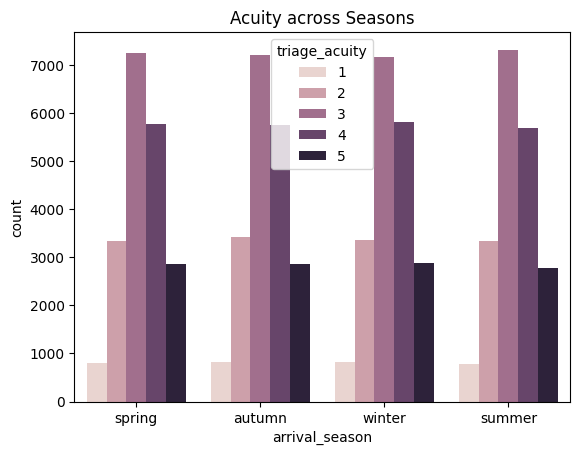

In [22]:
sns.countplot(x = 'arrival_season' , hue = 'triage_acuity' , data = df)
plt.title('Acuity across Seasons')
plt.show()

In [23]:
# we see all seasons are identical , so we drop this feature
df = df.drop('arrival_season' , axis = 1)

In [24]:
df.head()
df.columns

Index(['patient_id', 'site_id', 'triage_nurse_id', 'arrival_mode',
       'arrival_hour', 'arrival_month', 'shift', 'age', 'age_group', 'sex',
       'language', 'insurance_type', 'transport_origin', 'pain_location',
       'mental_status_triage', 'chief_complaint_system',
       'num_prior_ed_visits_12m', 'num_prior_admissions_12m',
       'num_active_medications', 'num_comorbidities', 'systolic_bp',
       'diastolic_bp', 'mean_arterial_pressure', 'pulse_pressure',
       'heart_rate', 'respiratory_rate', 'temperature_c', 'spo2', 'gcs_total',
       'pain_score', 'weight_kg', 'height_cm', 'bmi', 'shock_index',
       'news2_score', 'disposition', 'ed_los_hours', 'triage_acuity',
       'day_sin', 'day_cos'],
      dtype='object')

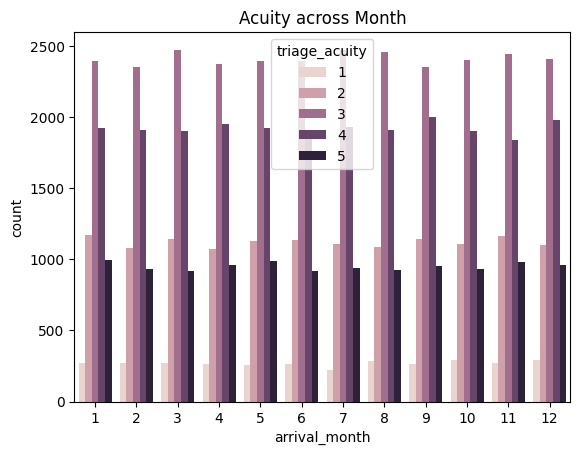

In [25]:
# checking monthly behavior with target feature
sns.countplot(x = 'arrival_month' , hue = 'triage_acuity' , data = df)
plt.title('Acuity across Month')
plt.show()

In [26]:
# so we drop thius feature too
df = df.drop('arrival_month' , axis=1)

In [27]:
### encoding done till arrival_mode , 
# have to start from arrival_hour

df.head()

,patient_id,site_id,triage_nurse_id,arrival_mode,arrival_hour,shift,age,age_group,sex,language,...,weight_kg,height_cm,bmi,shock_index,news2_score,disposition,ed_los_hours,triage_acuity,day_sin,day_cos
0,TG-UXRGA9UCO,1,1653,1,6,morning,43,middle_aged,M,Finnish,...,52.3,165.4,19.1,0.725,8,discharged,7.35,2,0.000000,1.000000
1,TG-B19DBBS2G,2,1619,1,6,morning,72,elderly,F,Russian,...,73.3,164.4,27.1,0.739,1,discharged,0.70,5,0.433884,-0.900969
2,TG-GZ97W7M6V,3,1557,1,8,morning,82,elderly,M,English,...,77.1,183.7,22.8,0.798,2,discharged,0.63,5,-0.974928,-0.222521
3,TG-THIB2TN9Q,3,1632,2,7,morning,50,middle_aged,F,Finnish,...,49.6,172.6,16.6,0.812,2,discharged,1.99,3,-0.781831,0.623490
4,TG-J3U3LQ2QY,3,1680,1,5,night,62,middle_aged,M,Finnish,...,71.9,173.4,23.9,0.812,2,transferred,3.58,3,0.781831,0.623490


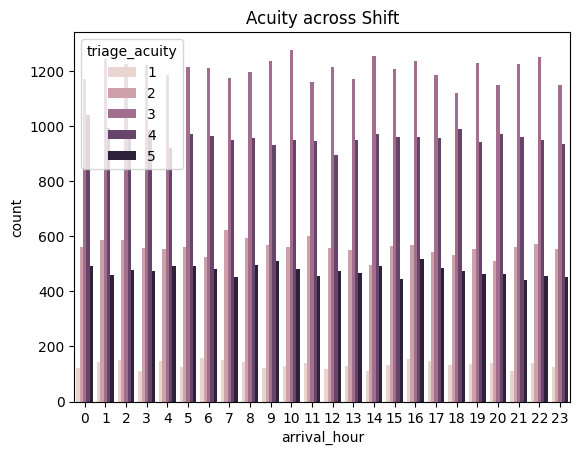

In [28]:
sns.countplot(x = 'arrival_hour' , hue = 'triage_acuity' , data = df)
plt.title('Acuity across Shift')
plt.show()

In [29]:
df = df.drop('arrival_hour' , axis = 1)

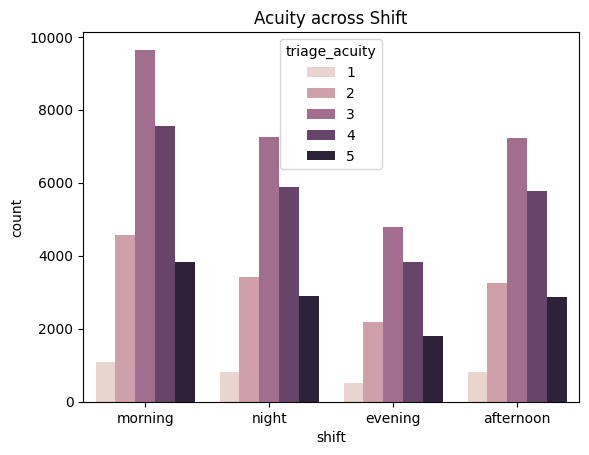

In [30]:
# checking arrival shift distribution
sns.countplot(x = 'shift' , hue = 'triage_acuity' , data = df)
plt.title('Acuity across Shift')
plt.show()

In [31]:
## shift also follows same pattern eevrywhere , traige = 3 is highest
# so we drop it
df = df.drop('shift' , axis = 1)

In [32]:
### observing age group
num_age_groups = df['age_group'].value_counts()
num_age_groups

age_group
middle_aged    27889
young_adult    23863
elderly        21653
pediatric       6595
Name: count, dtype: int64

In [33]:
index_age_groups = df['age_group'].value_counts().index
index_age_groups

Index(['middle_aged', 'young_adult', 'elderly', 'pediatric'], dtype='object', name='age_group')

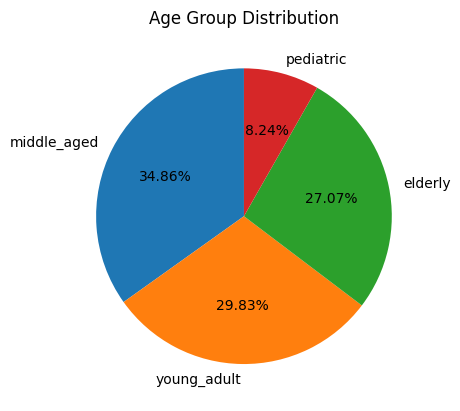

In [34]:
plt.pie(
    num_age_groups , 
    labels = index_age_groups , 
    autopct = '%1.2f%%' , 
    startangle=90
)
plt.title('Age Group Distribution')
plt.show()

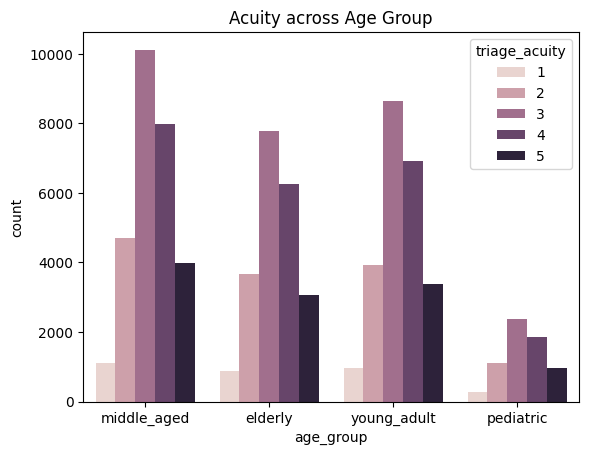

In [35]:
sns.countplot(x = 'age_group' , hue = 'triage_acuity' , data = df)
plt.title('Acuity across Age Group')
plt.show()

In [36]:
## encoding age group
df['age_group'] = df['age_group'].map({
    'pediatric' : 0,
    'young_adult' : 1,
    'middle_aged' : 2,
    'elderly' : 3
})

In [37]:
# cHECKING language
df['language'].unique()

array(['Finnish', 'Russian', 'English', 'Arabic', 'Estonian', 'Somali',
       'Swedish', 'Other'], dtype=object)

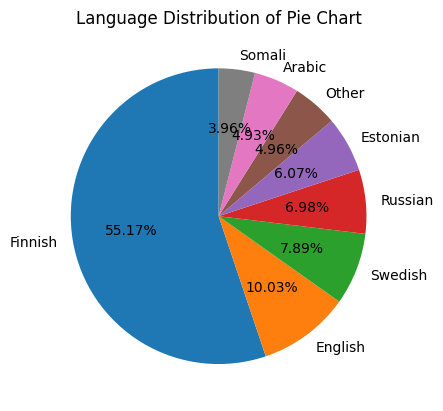

In [38]:
num_lang = df['language'].value_counts()
num_lang

index_lang = df['language'].value_counts().index
index_lang


plt.pie(
    num_lang , 
    labels = index_lang , 
    autopct = '%1.2f%%' , 
    startangle=90
)
plt.title('Language Distribution of Pie Chart')
plt.show()

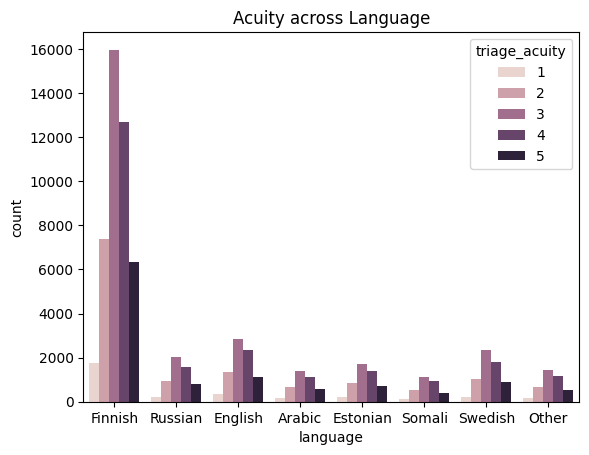

In [39]:
sns.countplot(x = 'language' , hue = 'triage_acuity' , data = df)
plt.title('Acuity across Language')
plt.show()

In [40]:
# %age plot for language column
pd.crosstab(df['language'] , df['triage_acuity'] , normalize = 'index')

triage_acuity,1,2,3,4,5
language,,,,,
Arabic,0.041329,0.171146,0.358266,0.279665,0.149594
English,0.043245,0.167996,0.355434,0.293993,0.139332
Estonian,0.041581,0.177851,0.352408,0.282215,0.145945
Finnish,0.040173,0.167195,0.361694,0.287488,0.143449
Other,0.041583,0.165827,0.367440,0.288810,0.136341
Russian,0.039377,0.167353,0.363164,0.285842,0.144263
Somali,0.037224,0.174132,0.357413,0.302208,0.129022
Swedish,0.037055,0.162787,0.373872,0.284719,0.141568


In [41]:
# removing language column
df = df.drop('language' , axis=1)
df.head()

,patient_id,site_id,triage_nurse_id,arrival_mode,age,age_group,sex,insurance_type,transport_origin,pain_location,...,weight_kg,height_cm,bmi,shock_index,news2_score,disposition,ed_los_hours,triage_acuity,day_sin,day_cos
0,TG-UXRGA9UCO,1,1653,1,43,2,M,public,public_space,extremity,...,52.3,165.4,19.1,0.725,8,discharged,7.35,2,0.000000,1.000000
1,TG-B19DBBS2G,2,1619,1,72,3,F,military,home,extremity,...,73.3,164.4,27.1,0.739,1,discharged,0.70,5,0.433884,-0.900969
2,TG-GZ97W7M6V,3,1557,1,82,3,M,none,nursing_home,abdomen,...,77.1,183.7,22.8,0.798,2,discharged,0.63,5,-0.974928,-0.222521
3,TG-THIB2TN9Q,3,1632,2,50,2,F,private,outdoor,abdomen,...,49.6,172.6,16.6,0.812,2,discharged,1.99,3,-0.781831,0.623490
4,TG-J3U3LQ2QY,3,1680,1,62,2,M,public,home,multiple,...,71.9,173.4,23.9,0.812,2,transferred,3.58,3,0.781831,0.623490


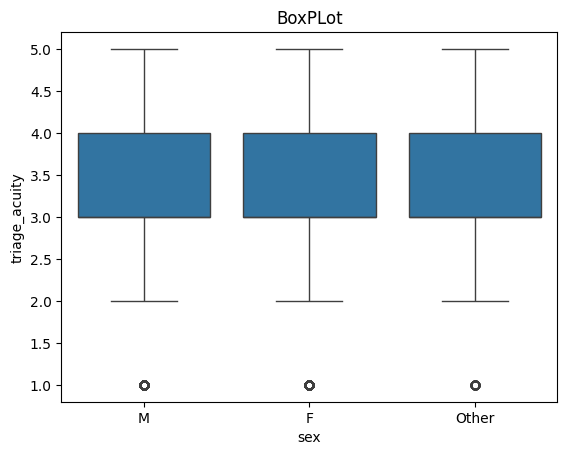

In [42]:
## Boxplot of sex with triage acuity
sns.boxplot(x = 'sex' , y = 'triage_acuity' , data = df)
plt.title('BoxPLot')
plt.show()

In [43]:
## Checking the percentage plot of sex column
pd.crosstab(df['sex'] , df['triage_acuity'] , normalize = 'index')

triage_acuity,1,2,3,4,5
sex,,,,,
F,0.040184,0.168770,0.360916,0.287216,0.142914
M,0.040254,0.167457,0.362396,0.287929,0.141964
Other,0.042575,0.161994,0.356698,0.295431,0.143302


In [44]:
# dropping sex column as it's acuity is same for male and female
df = df.drop('sex' , axis = 1)

In [45]:
df.head()

,patient_id,site_id,triage_nurse_id,arrival_mode,age,age_group,insurance_type,transport_origin,pain_location,mental_status_triage,...,weight_kg,height_cm,bmi,shock_index,news2_score,disposition,ed_los_hours,triage_acuity,day_sin,day_cos
0,TG-UXRGA9UCO,1,1653,1,43,2,public,public_space,extremity,drowsy,...,52.3,165.4,19.1,0.725,8,discharged,7.35,2,0.000000,1.000000
1,TG-B19DBBS2G,2,1619,1,72,3,military,home,extremity,alert,...,73.3,164.4,27.1,0.739,1,discharged,0.70,5,0.433884,-0.900969
2,TG-GZ97W7M6V,3,1557,1,82,3,none,nursing_home,abdomen,alert,...,77.1,183.7,22.8,0.798,2,discharged,0.63,5,-0.974928,-0.222521
3,TG-THIB2TN9Q,3,1632,2,50,2,private,outdoor,abdomen,alert,...,49.6,172.6,16.6,0.812,2,discharged,1.99,3,-0.781831,0.623490
4,TG-J3U3LQ2QY,3,1680,1,62,2,public,home,multiple,alert,...,71.9,173.4,23.9,0.812,2,transferred,3.58,3,0.781831,0.623490


In [46]:
# Making a function of top 3 visualization techniques of a column to save our time

def top3visuals(df , col , target = 'triage_acuity'):
    plt.figure(figsize = (18 , 12))  # width = 18 , height = 12

    # countplot
    plt.subplot(2 , 3 , 1)  # grid = 2 rows * 3 columns ,  postion = 1
    sns.countplot(x = col ,hue = target ,  data = df)
    plt.title(f" countplot distribution of {col} vs {target}")
    plt.xticks(rotation = 45) # for rotaing readability

    # %age plot
    plt.subplot(2 , 3 , 2)   # grid = 2 rows * 3 columns ,  postion = 2
    percent = pd.crosstab(df[col] , df[target] , normalize = 'index')# normalize='index' means we want = row-wise percentage
    # perecnt = is a daatframe of percentages
    percent.plot(kind = 'bar' , stacked = True , ax = plt.gca())  # we are now plotting this dataframe called percent , and kind = 'bar' means vertical bar chart , stacked = 'True' means each bar is on top of other making combined %age as 100% and plt.gca() = “get current axis”
    plt.title(f"Percentage Plot for {col} v/s {target}")
    plt.xticks(rotation = 45)

    # pie chart
    plt.subplot(2 , 3 , 3)   # grid = 2 rows * 3 columns ,  postion = 3
    values = df[col].value_counts()
    index = df[col].value_counts().index
    plt.pie(values , labels = index , startangle=90 , autopct = '%1.2f%%')
    plt.title(f"PIE CHART DISTRIBUTION of {col}")

    plt.tight_layout()
    plt.show()

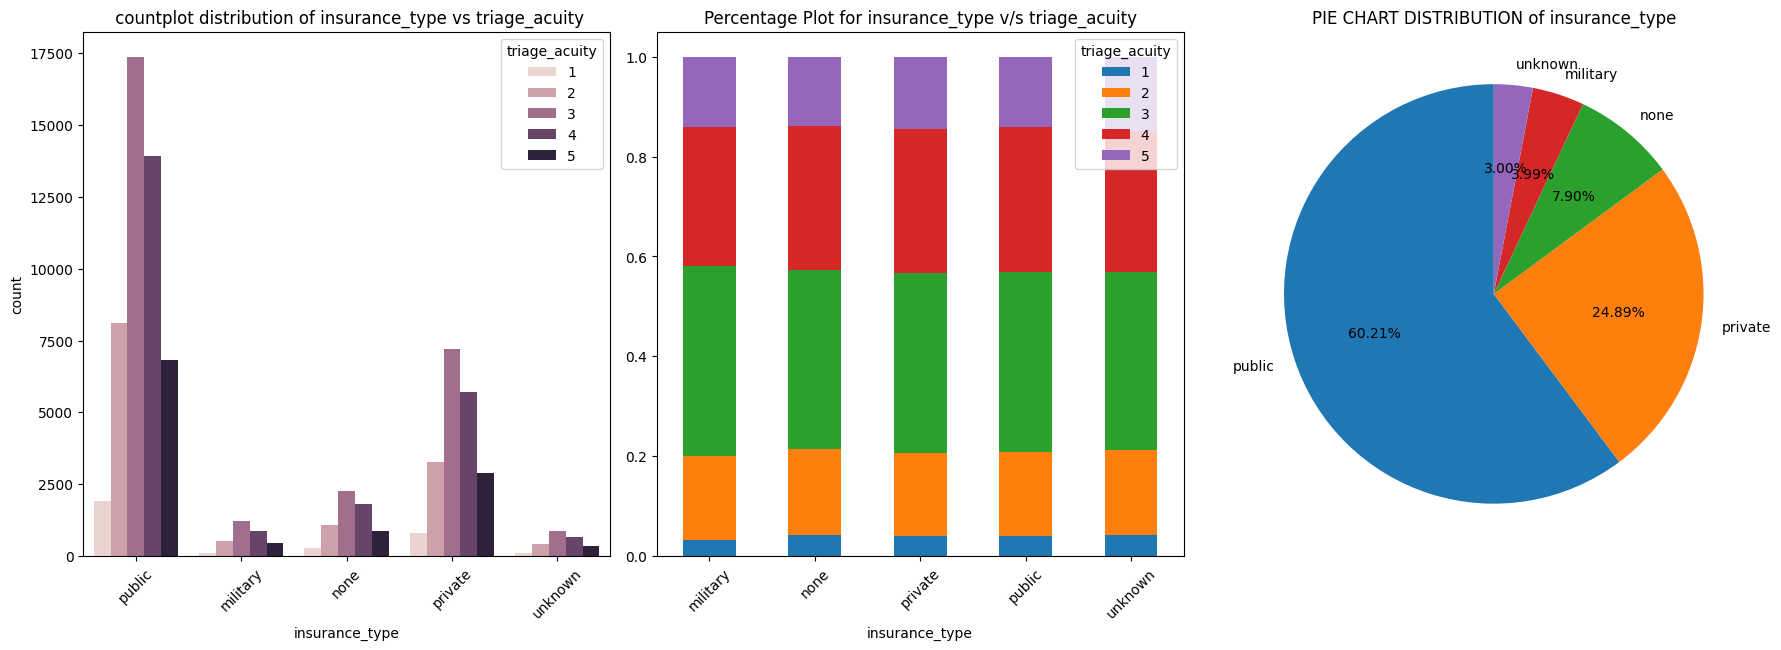

In [47]:
top3visuals(df , 'insurance_type')

In [48]:
# in the above figure we see acuity 3 is dominating everwhere , so 'insurance_type' is a weak feature
# dropping it
df = df.drop('insurance_type' , axis = 1)

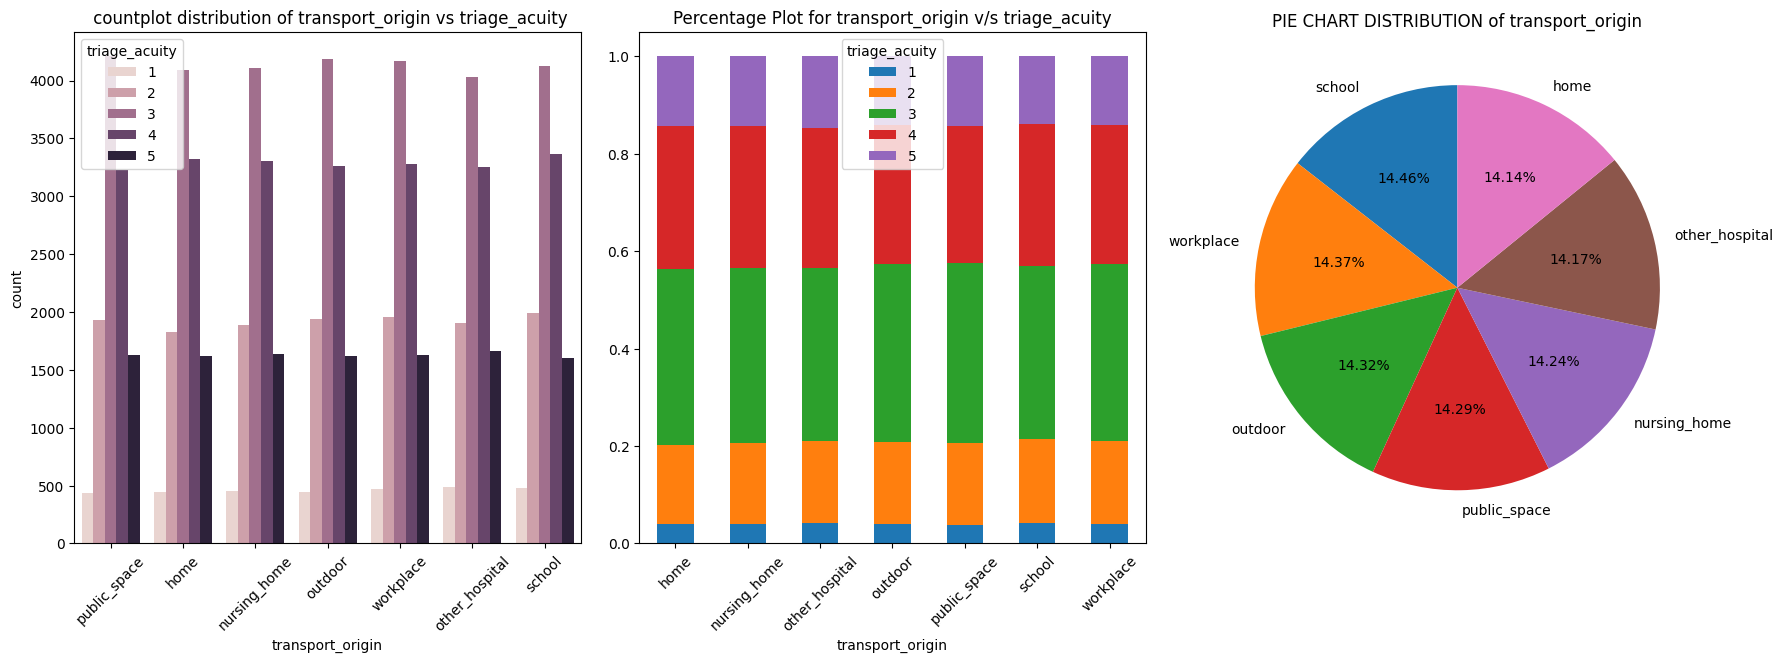

In [49]:
# checking transport orgin column
top3visuals(df , 'transport_origin')

In [50]:
df = df.drop('transport_origin' , axis = 1)

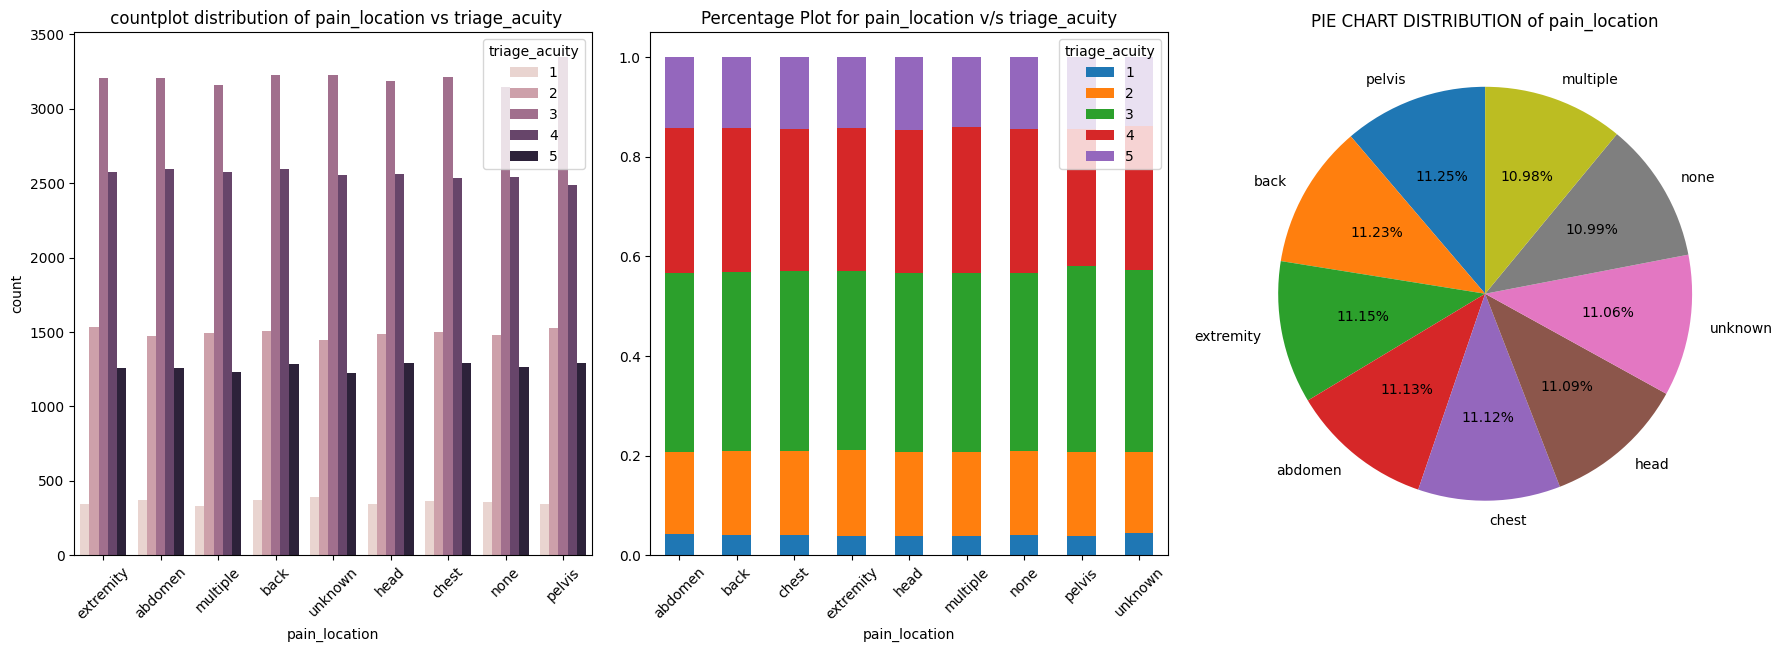

In [51]:
# checking pain location
top3visuals(df , 'pain_location')

In [52]:
df['pain_location'].unique()

array(['extremity', 'abdomen', 'multiple', 'back', 'unknown', 'head',
       'chest', 'none', 'pelvis'], dtype=object)

In [53]:
### as this is not a real dataset , so above distribution follows a similar patter , but still we dont remove it , because pain location is an important factor for triage acuity

# encoding pain location using one hot encoding

# first merging unknown and none
df['pain_location'] = df['pain_location'].replace({
    'unknown': 'other',
    'none': 'other'
})

df = pd.get_dummies(df , columns = ['pain_location'] , drop_first = True)

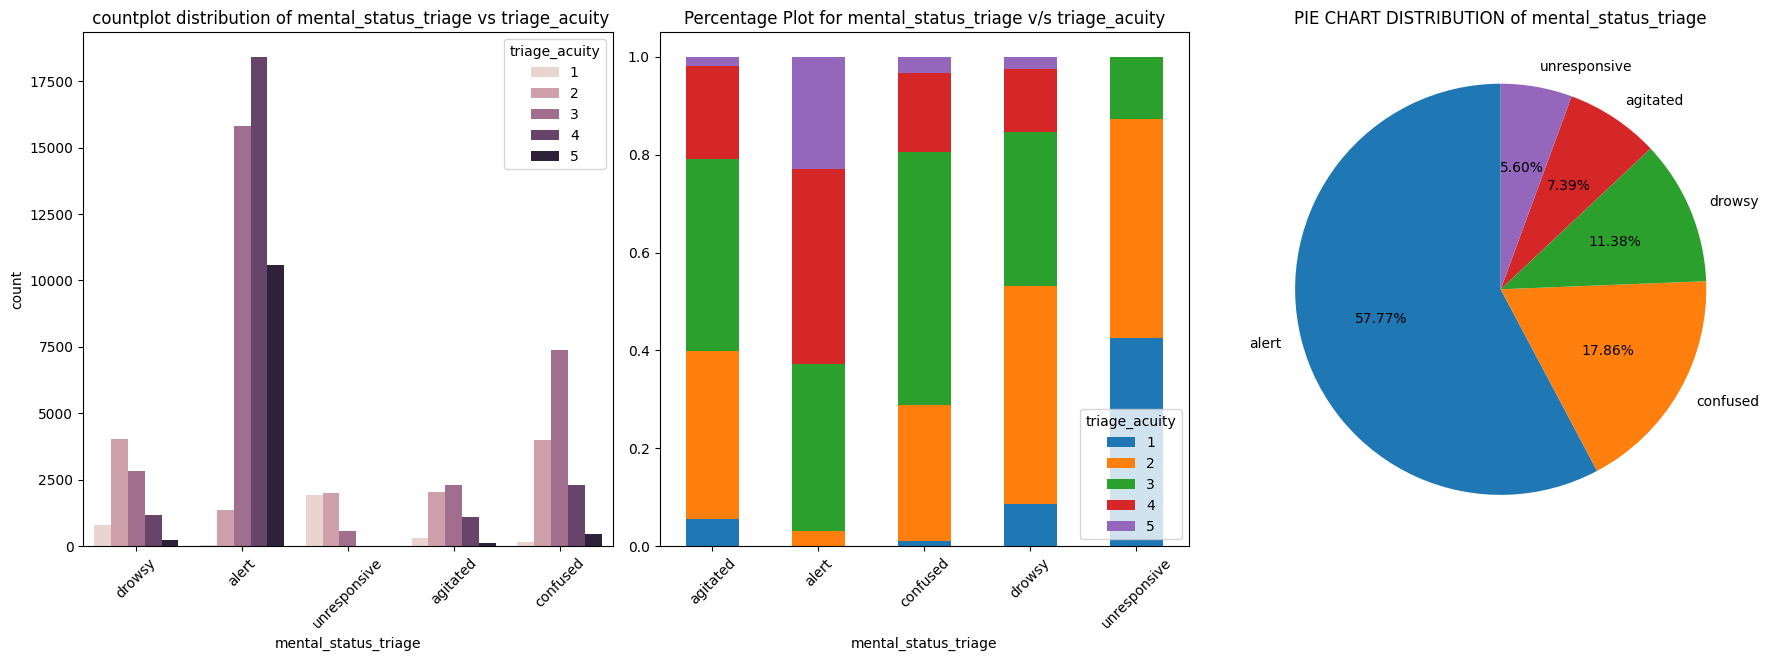

In [54]:
# coming on mental_status_triage
top3visuals(df , 'mental_status_triage')

In [55]:
## Mental status triage is a very usewfull feature fpr determining triage acuity , so we keep it.

# alert < drowsy < confused < agitated < unresponsive

# ordinal encoding it
mental_status = {
    'alert' : 0,
    'drowsy' : 1,
    'confused' : 2,
    'agitated' : 3,
    'unresponsive' : 4
}
df['mental_status_triage'] = df['mental_status_triage'].map(mental_status)

In [56]:
df.head()

,patient_id,site_id,triage_nurse_id,arrival_mode,age,age_group,mental_status_triage,chief_complaint_system,num_prior_ed_visits_12m,num_prior_admissions_12m,...,triage_acuity,day_sin,day_cos,pain_location_back,pain_location_chest,pain_location_extremity,pain_location_head,pain_location_multiple,pain_location_other,pain_location_pelvis
0,TG-UXRGA9UCO,1,1653,1,43,2,1,neurological,0,0,...,2,0.000000,1.000000,False,False,True,False,False,False,False
1,TG-B19DBBS2G,2,1619,1,72,3,0,genitourinary,0,0,...,5,0.433884,-0.900969,False,False,True,False,False,False,False
2,TG-GZ97W7M6V,3,1557,1,82,3,0,other,0,0,...,5,-0.974928,-0.222521,False,False,False,False,False,False,False
3,TG-THIB2TN9Q,3,1632,2,50,2,0,dermatological,3,1,...,3,-0.781831,0.623490,False,False,False,False,False,False,False
4,TG-J3U3LQ2QY,3,1680,1,62,2,0,dermatological,2,0,...,3,0.781831,0.623490,False,False,False,False,True,False,False


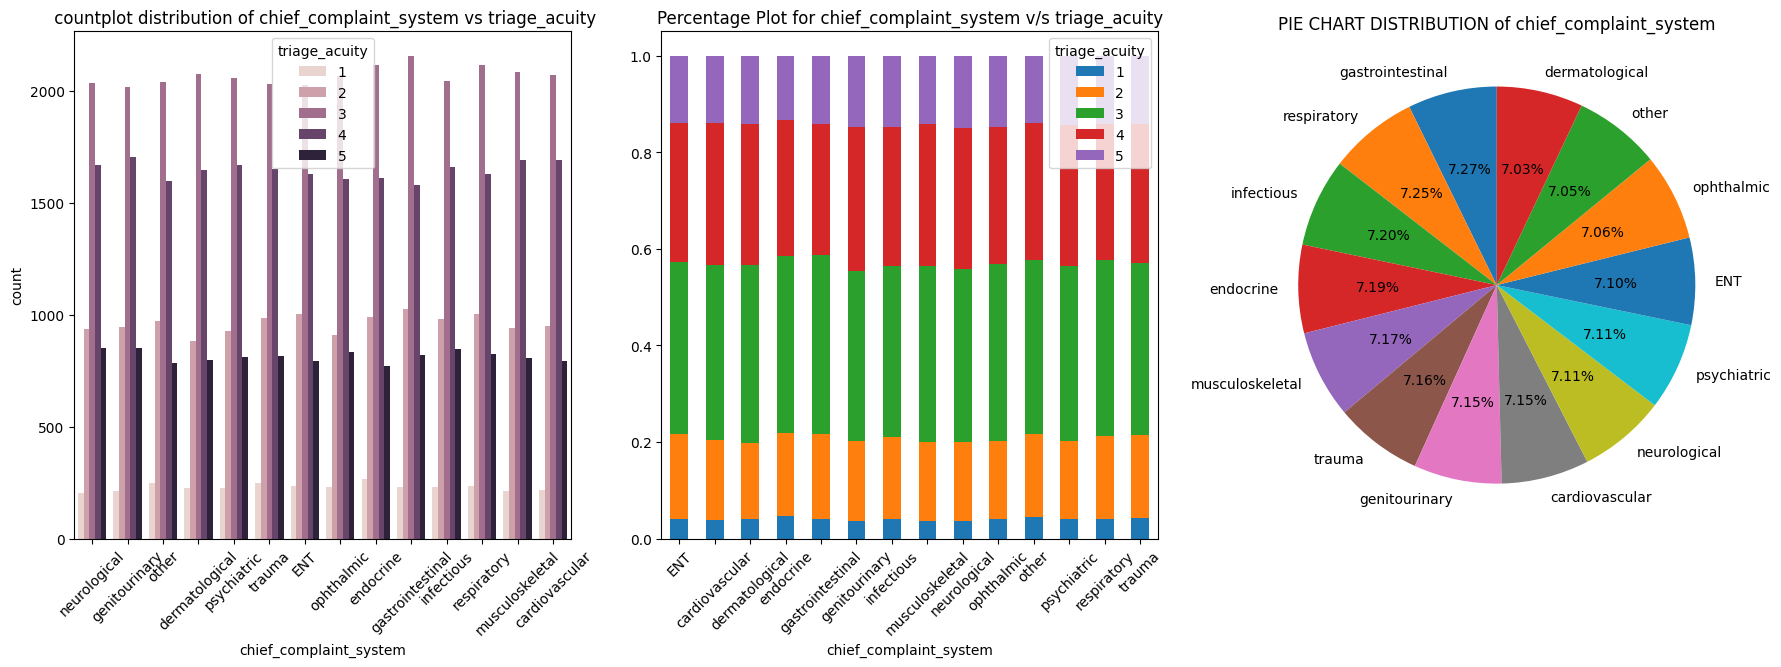

In [57]:
# chief complaint system
top3visuals(df , 'chief_complaint_system')

In [58]:
# chief complaint system is an imp. feature irrespective of its distribution

In [59]:
df['chief_complaint_system'].unique()

array(['neurological', 'genitourinary', 'other', 'dermatological',
       'psychiatric', 'trauma', 'ENT', 'ophthalmic', 'endocrine',
       'gastrointestinal', 'infectious', 'respiratory', 'musculoskeletal',
       'cardiovascular'], dtype=object)

In [60]:
# 3 grouping imp ones to avoid noise

df['chief_complaint_system'] = df['chief_complaint_system'].replace({
    'neurological' : 'critical',
    'trauma' : 'critical',
    'respiratory' : 'critical',
    'cardiovascular' : 'crticial',


    'gastrointestinal' : 'moderate',
    'infectious' : 'moderate',
    'endocrine' : 'moderate',

    'dermatological' : 'mild',
    'ophthalmic' : 'mild',
    'ENT' : 'mild',

    'psychiatric' : 'special',
    'genitourunary' : 'special',
    'musculoskeletal' : 'special',
    'other' : 'special'

})

In [61]:
df = pd.get_dummies(df , columns = ['chief_complaint_system'] , drop_first = True)

In [62]:
df.columns

Index(['patient_id', 'site_id', 'triage_nurse_id', 'arrival_mode', 'age',
       'age_group', 'mental_status_triage', 'num_prior_ed_visits_12m',
       'num_prior_admissions_12m', 'num_active_medications',
       'num_comorbidities', 'systolic_bp', 'diastolic_bp',
       'mean_arterial_pressure', 'pulse_pressure', 'heart_rate',
       'respiratory_rate', 'temperature_c', 'spo2', 'gcs_total', 'pain_score',
       'weight_kg', 'height_cm', 'bmi', 'shock_index', 'news2_score',
       'disposition', 'ed_los_hours', 'triage_acuity', 'day_sin', 'day_cos',
       'pain_location_back', 'pain_location_chest', 'pain_location_extremity',
       'pain_location_head', 'pain_location_multiple', 'pain_location_other',
       'pain_location_pelvis', 'chief_complaint_system_crticial',
       'chief_complaint_system_genitourinary', 'chief_complaint_system_mild',
       'chief_complaint_system_moderate', 'chief_complaint_system_special'],
      dtype='object')

In [63]:
cat_cols = df.select_dtypes(include = ['object' , 'string' , 'category']).columns
cat_cols

Index(['patient_id', 'disposition'], dtype='object')

In [64]:
df['disposition'].unique()

array(['discharged', 'transferred', 'observation', 'admitted', 'deceased',
       'lwbs', 'lama'], dtype=object)

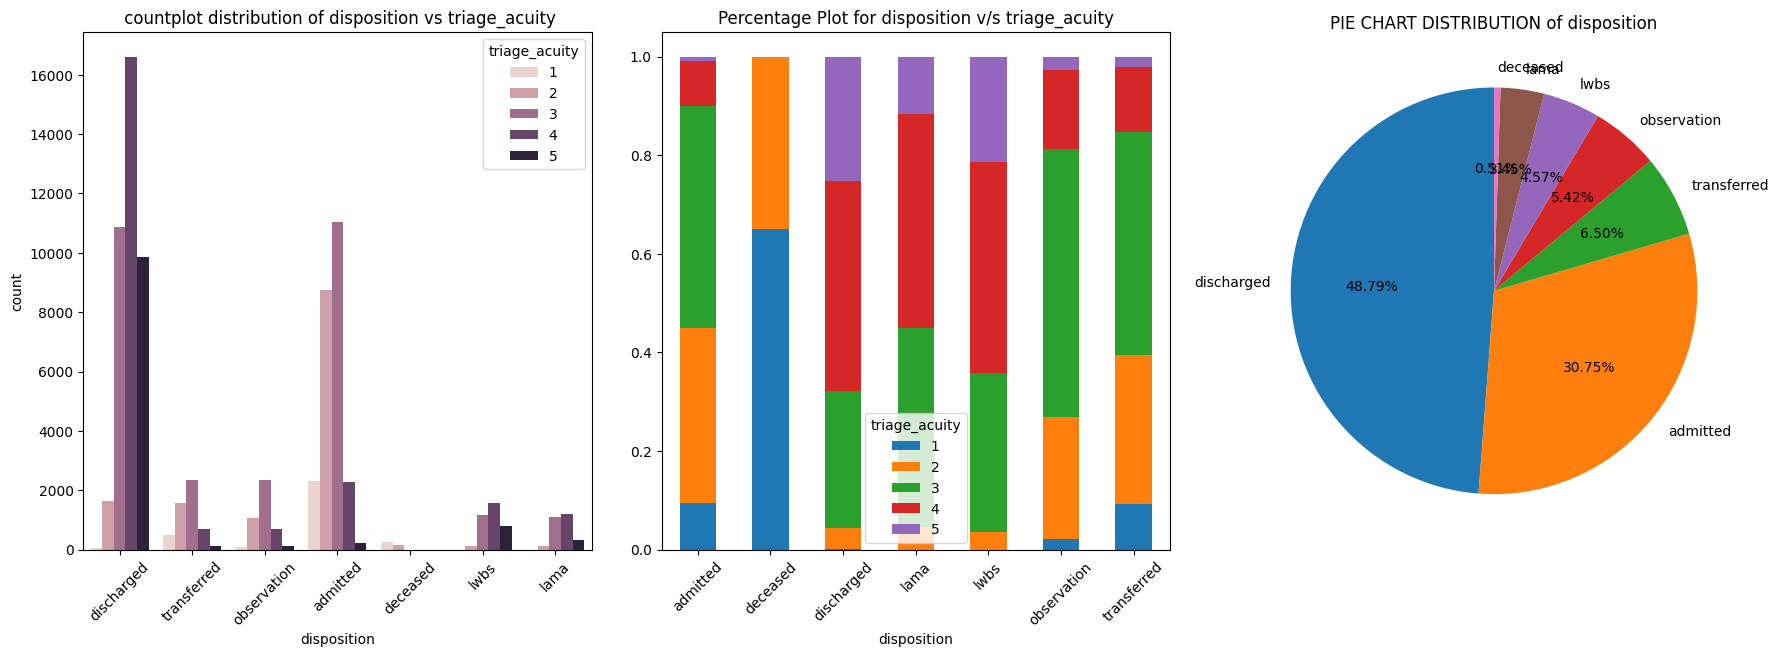

In [65]:
top3visuals(df , 'disposition')

In [66]:
### So we will encode this feature using target encoding 9 gives the average value of target variable instead of random numbers)

import category_encoders as ce

encoder = ce.TargetEncoder(cols = ['disposition'])
df['disposition'] = encoder.fit_transform(
    df['disposition'],
    df['triage_acuity']
)

In [67]:
df[['disposition', 'triage_acuity']].head()

,disposition,triage_acuity
0,3.884493,2
1,3.884493,5
2,3.884493,5
3,3.884493,3
4,2.688257,3


In [68]:
pd.set_option('display.max_columns' , None)

In [69]:
df.head(10)

,patient_id,site_id,triage_nurse_id,arrival_mode,age,age_group,mental_status_triage,num_prior_ed_visits_12m,num_prior_admissions_12m,num_active_medications,num_comorbidities,systolic_bp,diastolic_bp,mean_arterial_pressure,pulse_pressure,heart_rate,respiratory_rate,temperature_c,spo2,gcs_total,pain_score,weight_kg,height_cm,bmi,shock_index,news2_score,disposition,ed_los_hours,triage_acuity,day_sin,day_cos,pain_location_back,pain_location_chest,pain_location_extremity,pain_location_head,pain_location_multiple,pain_location_other,pain_location_pelvis,chief_complaint_system_crticial,chief_complaint_system_genitourinary,chief_complaint_system_mild,chief_complaint_system_moderate,chief_complaint_system_special
0,TG-UXRGA9UCO,1,1653,1,43,2,1,0,0,4,8,79.0,57.5,64.7,21.5,57.3,17.9,37.0,92.1,14,7,52.3,165.4,19.1,0.725,8,3.884493,7.35,2,0.000000,1.000000,False,False,True,False,False,False,False,False,False,False,False,False
1,TG-B19DBBS2G,2,1619,1,72,3,0,0,0,10,8,131.7,93.4,106.2,38.3,97.3,17.2,36.9,99.4,15,-1,73.3,164.4,27.1,0.739,1,3.884493,0.70,5,0.433884,-0.900969,False,False,True,False,False,False,False,False,True,False,False,False
2,TG-GZ97W7M6V,3,1557,1,82,3,0,0,0,13,14,94.7,83.3,87.1,11.4,75.6,14.7,37.3,100.0,15,3,77.1,183.7,22.8,0.798,2,3.884493,0.63,5,-0.974928,-0.222521,False,False,False,False,False,False,False,False,False,False,False,True
3,TG-THIB2TN9Q,3,1632,2,50,2,0,3,1,4,3,134.2,51.8,79.3,82.4,109.0,17.6,38.2,96.0,15,7,49.6,172.6,16.6,0.812,2,3.884493,1.99,3,-0.781831,0.623490,False,False,False,False,False,False,False,False,False,True,False,False
4,TG-J3U3LQ2QY,3,1680,1,62,2,0,2,0,10,17,140.1,75.4,97.0,64.7,113.7,17.6,36.6,99.1,15,4,71.9,173.4,23.9,0.812,2,2.688257,3.58,3,0.781831,0.623490,False,False,False,False,True,False,False,False,False,True,False,False
5,TG-1UXV144MT,4,1534,1,44,2,0,1,1,3,4,133.1,83.0,99.7,50.1,89.4,18.9,37.2,96.4,15,5,69.3,183.2,20.6,0.672,0,2.922297,5.53,3,0.000000,1.000000,True,False,False,False,False,False,False,False,False,True,False,False
6,TG-VFKLMUXJJ,1,1653,1,62,2,0,0,0,2,7,NaN,NaN,NaN,NaN,80.2,17.8,38.0,94.5,15,2,99.6,154.0,42.0,NaN,1,3.884493,3.73,4,0.433884,-0.900969,False,False,False,False,False,True,False,False,False,True,False,False
7,TG-WFM0W3TUS,2,1539,1,65,3,0,2,2,6,9,127.1,62.4,84.0,64.7,78.9,13.3,38.4,97.8,15,3,55.4,153.4,23.5,0.621,1,3.884493,5.11,3,0.974928,-0.222521,False,False,True,False,False,False,False,False,False,False,False,True
8,TG-NMIVSUYHH,1,1559,3,94,3,0,0,0,14,10,134.1,80.8,98.6,53.3,91.8,14.9,37.9,99.2,15,4,61.3,165.2,22.4,0.685,1,3.884493,1.40,5,0.781831,0.623490,False,False,False,False,False,False,False,False,False,False,False,False
9,TG-FPU1JAUHF,2,1587,1,56,2,0,2,0,4,6,84.9,78.3,80.5,6.6,86.4,13.8,37.1,98.5,15,-1,94.9,175.9,30.7,1.018,3,3.884493,2.85,4,-0.433884,-0.900969,True,False,False,False,False,False,False,False,False,False,False,False


#### Now coming to missing values

In [70]:
df.isna().sum()[df.isna().sum() > 0]

systolic_bp               4146
diastolic_bp              4146
mean_arterial_pressure    4146
pulse_pressure            4146
respiratory_rate          3067
temperature_c              574
shock_index               4146
dtype: int64

In [71]:
cols = [
    'systolic_bp',
    'diastolic_bp',
    'mean_arterial_pressure',
    'pulse_pressure',
    'respiratory_rate',
    'temperature_c',
    'shock_index',
    'triage_acuity'
]

df_selected = df[cols]

df_selected.head()

,systolic_bp,diastolic_bp,mean_arterial_pressure,pulse_pressure,respiratory_rate,temperature_c,shock_index,triage_acuity
0,79.0,57.5,64.7,21.5,17.9,37.0,0.725,2
1,131.7,93.4,106.2,38.3,17.2,36.9,0.739,5
2,94.7,83.3,87.1,11.4,14.7,37.3,0.798,5
3,134.2,51.8,79.3,82.4,17.6,38.2,0.812,3
4,140.1,75.4,97.0,64.7,17.6,36.6,0.812,3


In [72]:
for col in cols:
    df[col + '_missing'] = df[col].isna().astype(int)

In [73]:
for col in cols:
    df[col] = df[col].fillna(df[col].median())

In [74]:
df.isna().sum().sum()

0

In [75]:
df.isnull().sum()

patient_id                              0
site_id                                 0
triage_nurse_id                         0
arrival_mode                            0
age                                     0
age_group                               0
mental_status_triage                    0
num_prior_ed_visits_12m                 0
num_prior_admissions_12m                0
num_active_medications                  0
num_comorbidities                       0
systolic_bp                             0
diastolic_bp                            0
mean_arterial_pressure                  0
pulse_pressure                          0
heart_rate                              0
respiratory_rate                        0
temperature_c                           0
spo2                                    0
gcs_total                               0
pain_score                              0
weight_kg                               0
height_cm                               0
bmi                               

In [76]:
df.columns

Index(['patient_id', 'site_id', 'triage_nurse_id', 'arrival_mode', 'age',
       'age_group', 'mental_status_triage', 'num_prior_ed_visits_12m',
       'num_prior_admissions_12m', 'num_active_medications',
       'num_comorbidities', 'systolic_bp', 'diastolic_bp',
       'mean_arterial_pressure', 'pulse_pressure', 'heart_rate',
       'respiratory_rate', 'temperature_c', 'spo2', 'gcs_total', 'pain_score',
       'weight_kg', 'height_cm', 'bmi', 'shock_index', 'news2_score',
       'disposition', 'ed_los_hours', 'triage_acuity', 'day_sin', 'day_cos',
       'pain_location_back', 'pain_location_chest', 'pain_location_extremity',
       'pain_location_head', 'pain_location_multiple', 'pain_location_other',
       'pain_location_pelvis', 'chief_complaint_system_crticial',
       'chief_complaint_system_genitourinary', 'chief_complaint_system_mild',
       'chief_complaint_system_moderate', 'chief_complaint_system_special',
       'systolic_bp_missing', 'diastolic_bp_missing',
       'mean_

In [77]:
df = df.drop(['triage_acuity_missing' , 'disposition' , 'ed_los_hours'] , axis = True)

In [81]:
df.head()

,patient_id,site_id,triage_nurse_id,arrival_mode,age,age_group,mental_status_triage,num_prior_ed_visits_12m,num_prior_admissions_12m,num_active_medications,num_comorbidities,systolic_bp,diastolic_bp,mean_arterial_pressure,pulse_pressure,heart_rate,respiratory_rate,temperature_c,spo2,gcs_total,pain_score,weight_kg,height_cm,bmi,shock_index,news2_score,triage_acuity,day_sin,day_cos,pain_location_back,pain_location_chest,pain_location_extremity,pain_location_head,pain_location_multiple,pain_location_other,pain_location_pelvis,chief_complaint_system_crticial,chief_complaint_system_genitourinary,chief_complaint_system_mild,chief_complaint_system_moderate,chief_complaint_system_special,systolic_bp_missing,diastolic_bp_missing,mean_arterial_pressure_missing,pulse_pressure_missing,respiratory_rate_missing,temperature_c_missing,shock_index_missing
0,TG-UXRGA9UCO,1,1653,1,43,2,1,0,0,4,8,79.0,57.5,64.7,21.5,57.3,17.9,37.0,92.1,14,7,52.3,165.4,19.1,0.725,8,2,0.000000,1.000000,False,False,True,False,False,False,False,False,False,False,False,False,0,0,0,0,0,0,0
1,TG-B19DBBS2G,2,1619,1,72,3,0,0,0,10,8,131.7,93.4,106.2,38.3,97.3,17.2,36.9,99.4,15,-1,73.3,164.4,27.1,0.739,1,5,0.433884,-0.900969,False,False,True,False,False,False,False,False,True,False,False,False,0,0,0,0,0,0,0
2,TG-GZ97W7M6V,3,1557,1,82,3,0,0,0,13,14,94.7,83.3,87.1,11.4,75.6,14.7,37.3,100.0,15,3,77.1,183.7,22.8,0.798,2,5,-0.974928,-0.222521,False,False,False,False,False,False,False,False,False,False,False,True,0,0,0,0,0,0,0
3,TG-THIB2TN9Q,3,1632,2,50,2,0,3,1,4,3,134.2,51.8,79.3,82.4,109.0,17.6,38.2,96.0,15,7,49.6,172.6,16.6,0.812,2,3,-0.781831,0.623490,False,False,False,False,False,False,False,False,False,True,False,False,0,0,0,0,0,0,0
4,TG-J3U3LQ2QY,3,1680,1,62,2,0,2,0,10,17,140.1,75.4,97.0,64.7,113.7,17.6,36.6,99.1,15,4,71.9,173.4,23.9,0.812,2,3,0.781831,0.623490,False,False,False,False,True,False,False,False,False,True,False,False,0,0,0,0,0,0,0


In [78]:
df.duplicated().sum()  # means no duplicate value

0

In [79]:
df.shape

(80000, 48)

In [80]:
df.to_csv('training_set.csv' , index = False)

In [82]:
df.columns

Index(['patient_id', 'site_id', 'triage_nurse_id', 'arrival_mode', 'age',
       'age_group', 'mental_status_triage', 'num_prior_ed_visits_12m',
       'num_prior_admissions_12m', 'num_active_medications',
       'num_comorbidities', 'systolic_bp', 'diastolic_bp',
       'mean_arterial_pressure', 'pulse_pressure', 'heart_rate',
       'respiratory_rate', 'temperature_c', 'spo2', 'gcs_total', 'pain_score',
       'weight_kg', 'height_cm', 'bmi', 'shock_index', 'news2_score',
       'triage_acuity', 'day_sin', 'day_cos', 'pain_location_back',
       'pain_location_chest', 'pain_location_extremity', 'pain_location_head',
       'pain_location_multiple', 'pain_location_other', 'pain_location_pelvis',
       'chief_complaint_system_crticial',
       'chief_complaint_system_genitourinary', 'chief_complaint_system_mild',
       'chief_complaint_system_moderate', 'chief_complaint_system_special',
       'systolic_bp_missing', 'diastolic_bp_missing',
       'mean_arterial_pressure_missing', 'pu